# Customer Intelligence System using Classification and Clustering

## Objective

The objective of this project is to build an end-to-end Customer Intelligence System that can classify countries into different GDP categories and segment them into meaningful groups using machine learning techniques.

This project includes:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Classification Models
    - Logistic Regression
    - Random Forest
    - XGBoost
    - Voting Ensemble
- Clustering Techniques
    - Hierarchical Clustering
    - K-Means
    - DBSCAN
- PCA Visualization
- Business Insights Dashboard



In [4]:
# Import Libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

# Train Test Split
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram

# PCA
from sklearn.decomposition import PCA

# Display Settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [5]:
# Load Dataset
df = pd.read_csv("Country-data.csv")

print("Dataset Loaded Successfully\n")

print("Shape of Dataset :", df.shape)

print("\nFirst Five Rows")
display(df.head())

Dataset Loaded Successfully

Shape of Dataset : (167, 10)

First Five Rows


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
# Dataset Inspection
print("Dataset Information\n")
df.info()

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe().T)

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Missing Values

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows : 0

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [7]:
# Data Cleaning

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check missing values
print("Missing Values")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning :", df.shape)

Missing Values
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Dataset Shape After Cleaning : (167, 10)


## Exploratory Data Analysis (EDA)

EDA helps understand the relationships between socio-economic indicators and identify patterns within the dataset.

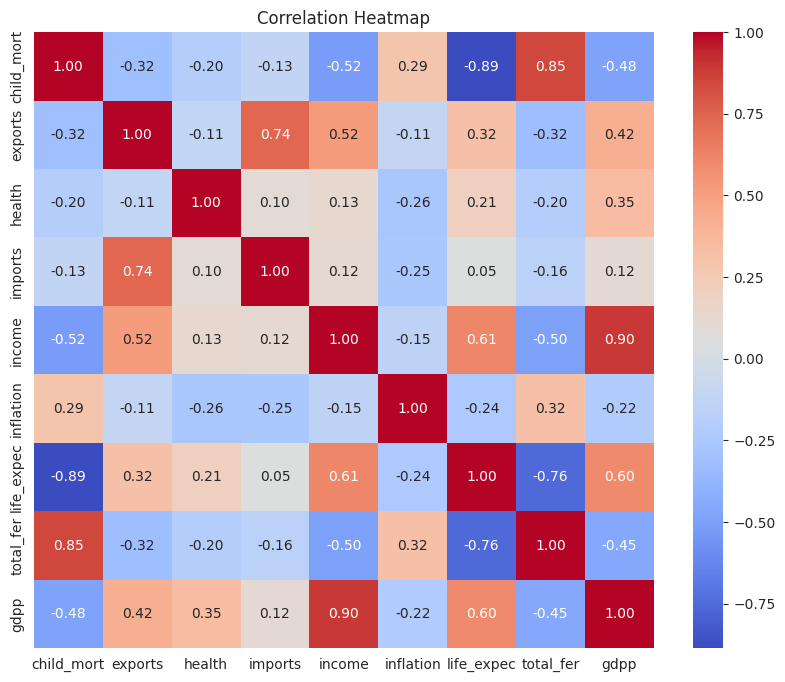

In [8]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap helps identify strong positive and negative relationships among the variables.

For example:

- Income and GDP per capita are positively correlated.
- Child mortality generally has a negative relationship with life expectancy.

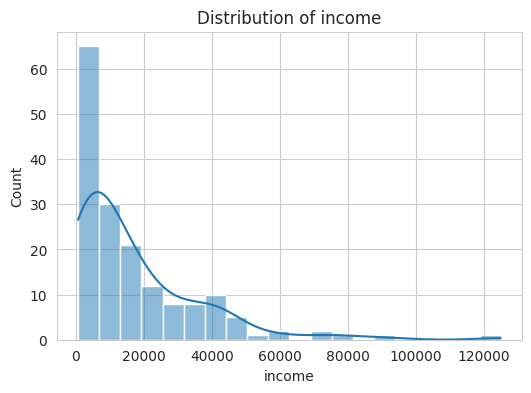

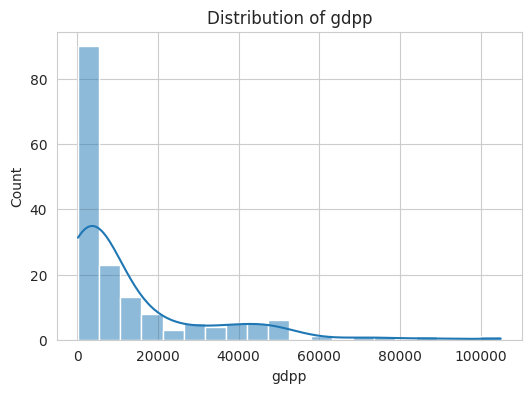

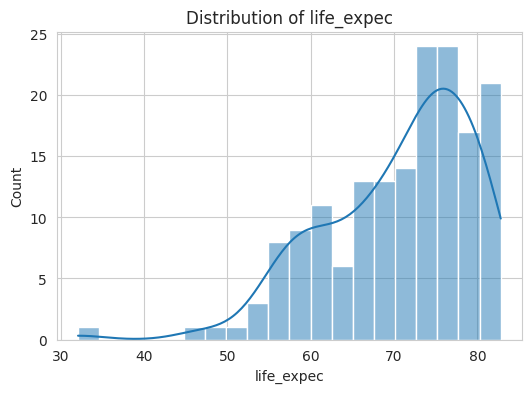

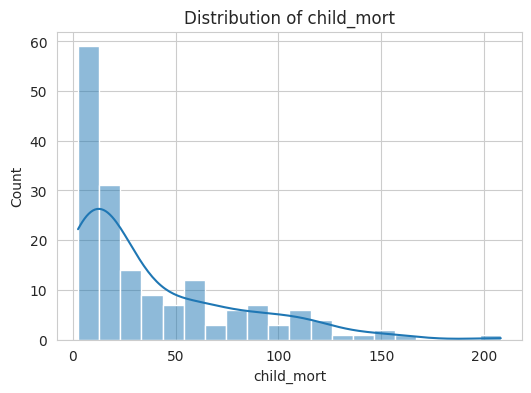

In [9]:
# Distribution Plots
important_cols = [
    "income",
    "gdpp",
    "life_expec",
    "child_mort"
]

for col in important_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

### Observation

The distribution plots help understand the spread and skewness of important economic indicators.

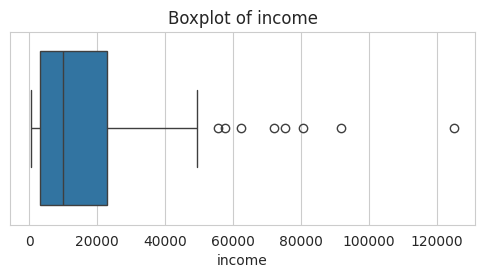

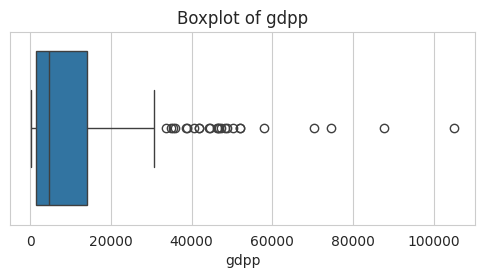

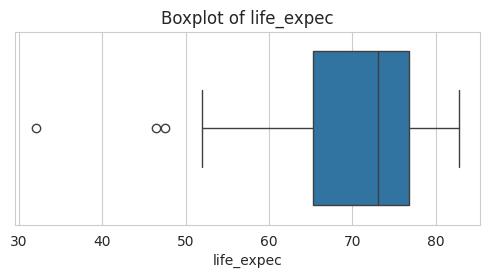

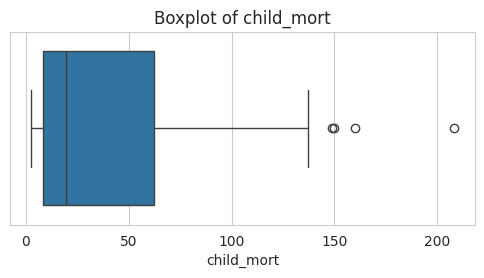

In [10]:
# Boxplots
for col in important_cols:

    plt.figure(figsize=(6,2.5))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

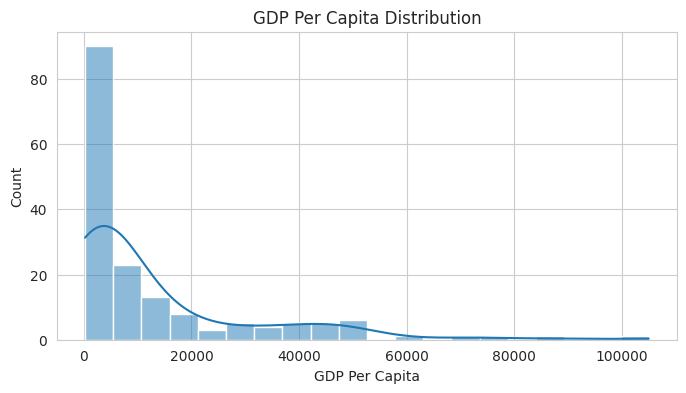

In [11]:
# ==========================
# GDP Distribution


plt.figure(figsize=(8,4))

sns.histplot(
    df["gdpp"],
    bins=20,
    kde=True
)

plt.title("GDP Per Capita Distribution")

plt.xlabel("GDP Per Capita")

plt.show()

## Feature Engineering

Feature engineering is the process of creating new variables from existing data to capture hidden patterns and improve model performance.

The following features are created:

- Income_Life_Index
- Import_Export_Ratio
- Health_Per_ChildMort
- Fertility_Health
- GDP_Potential

In [12]:
# Feature Engineering
# Combined economic and social development indicator
df["income_life_index"] = df["income"] * df["life_expec"]

# Trade balance indicator
df["import_export_ratio"] = (
    df["imports"] / (df["exports"] + 1)
)

# Healthcare effectiveness indicator
df["health_per_childmort"] = (
    df["health"] / (df["child_mort"] + 1)
)

# Fertility and healthcare relationship
df["fertility_health"] = (
    df["total_fer"] / (df["health"] + 1)
)

# GDP growth potential indicator
df["gdp_potential"] = (
    df["income"] * df["exports"]
)

print("New Features Added Successfully\n")

new_features = [
    "income_life_index",
    "import_export_ratio",
    "health_per_childmort",
    "fertility_health",
    "gdp_potential"
]

print(new_features)

New Features Added Successfully

['income_life_index', 'import_export_ratio', 'health_per_childmort', 'fertility_health', 'gdp_potential']


In [13]:
df[new_features].head()

,income_life_index,import_export_ratio,health_per_childmort,fertility_health,gdp_potential
0,90482.0,4.081818,0.083114,0.678322,16100.0
1,757659.0,1.675862,0.372159,0.218543,278040.0
2,986850.0,0.796954,0.147350,0.558994,495360.0
3,354590.0,0.677725,0.023750,1.600000,367570.0
4,1466880.0,1.266667,0.533628,0.302987,869050.0


### Observation

The engineered features combine multiple socio-economic indicators and help machine learning models capture relationships that may not be directly visible from the original dataset.

## Creating Target Variable

Since this is a classification problem, countries are divided into three GDP categories:

- Low GDP
- Medium GDP
- High GDP

The categories are created using equal-sized quantiles.

In [14]:
# Create GDP Classes
df["gdp_class"] = pd.qcut(
    df["gdpp"],
    q=3,
    labels=[0, 1, 2]
)

print("GDP Class Distribution\n")

print(df["gdp_class"].value_counts())

GDP Class Distribution

gdp_class
0    56
2    56
1    55
Name: count, dtype: int64


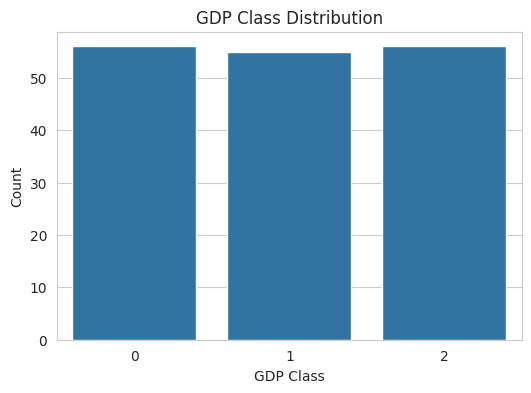

In [15]:
# Visualize GDP Classes

plt.figure(figsize=(6,4))

sns.countplot(x="gdp_class",data=df)

plt.title("GDP Class Distribution")

plt.xlabel("GDP Class")

plt.ylabel("Count")

plt.show()

### GDP Class Meaning

| Class | Description |
|--------|-------------|
| 0 | Low GDP Countries |
| 1 | Medium GDP Countries |
| 2 | High GDP Countries |

## Feature Selection


In [16]:
# Feature Selection
feature_cols = [
    "child_mort",
    "exports",
    "health",
    "imports",
    "income",
    "inflation",
    "life_expec",
    "total_fer",
    "income_life_index",
    "import_export_ratio",
    "health_per_childmort",
    "fertility_health",
    "gdp_potential"
]

X = df[feature_cols]

y = df["gdp_class"]

selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features\n")

for feature in selected_features:
    print(feature)

Selected Features

child_mort
exports
income
life_expec
total_fer
income_life_index
import_export_ratio
health_per_childmort
fertility_health
gdp_potential


In [17]:
# Feature Scores

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(by="Score",ascending=False)
display(feature_scores)

,Feature,Score
4,income,125.490914
8,income_life_index,124.023422
6,life_expec,111.016955
0,child_mort,104.365355
10,health_per_childmort,90.906639
7,total_fer,81.133633
11,fertility_health,47.852925
12,gdp_potential,29.404655
1,exports,16.663702
9,import_export_ratio,12.339573


### Feature Engineering Summary

In this step:

- New socio-economic indicators were created.
- Countries were classified into GDP categories.
- The most informative features were selected using SelectKBest.

The selected features will be used for building classification models.

## Build Classification Models

The objective of this step is to classify countries into different GDP categories using supervised machine learning algorithms.

The following models are implemented:

- Logistic Regression
- Random Forest
- XGBoost
- Voting Ensemble

The performance of each model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Cross Validation

In [18]:
# Train Test Split
X = df[selected_features]

y = df["gdp_class"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 133
Testing Samples  : 34


## Feature Scaling

Machine learning algorithms perform better when numerical features are on a similar scale.

StandardScaler is used to standardize the data.

In [19]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [20]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000,random_state=42)

log_model.fit(X_train_scaled,y_train)

log_pred = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test,log_pred)

log_pre = precision_score(y_test,log_pred,average="weighted")

log_rec = recall_score(y_test,log_pred,average="weighted")

log_f1 = f1_score(y_test,log_pred,average="weighted")

print("Logistic Regression")
print("------------------------")
print("Accuracy :", log_acc)
print("Precision :", log_pre)
print("Recall :", log_rec)
print("F1 Score :", log_f1)

Logistic Regression
------------------------
Accuracy : 0.9117647058823529
Precision : 0.9166666666666667
Recall : 0.9117647058823529
F1 Score : 0.9129825843380831


## Random Forest with Hyperparameter Tuning

In [46]:
# Random Forest

rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[3,5,7],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf_grid = GridSearchCV(rf,rf_params, cv=5, scoring="accuracy",n_jobs=-1)


rf_grid.fit(X_train_scaled,y_train)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test_scaled)

rf_acc = accuracy_score(y_test,rf_pred)

rf_pre = precision_score(y_test,rf_pred,average="weighted")

rf_rec = recall_score( y_test, rf_pred,average="weighted")

rf_f1 = f1_score(y_test,rf_pred,average="weighted")

print("Random Forest")
print("------------------------")
print("Best Parameters :", rf_grid.best_params_)

print("Accuracy :", rf_acc)

print("Precision :", rf_pre)

print("Recall :", rf_rec)

print("F1 Score :", rf_f1)

Random Forest
------------------------
Best Parameters : {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy : 0.8823529411764706
Precision : 0.8823529411764706
Recall : 0.8823529411764706
F1 Score : 0.8823529411764706


## XGBoost with Hyperparameter Tuning

In [47]:
# XGBoost
xgb = XGBClassifier(random_state=42,eval_metric="mlogloss")

xgb_params = {

    "n_estimators":[100,200,300],

    "max_depth":[3,4,5],

    "learning_rate":[0.01,0.05,0.1]

}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(
    X_train_scaled,
    y_train
)

best_xgb = xgb_grid.best_estimator_

xgb_pred = best_xgb.predict(
    X_test_scaled
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

xgb_pre = precision_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_rec = recall_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted"
)

print("XGBoost")
print("------------------------")

print("Best Parameters :", xgb_grid.best_params_)

print("Accuracy :", xgb_acc)

print("Precision :", xgb_pre)

print("Recall :", xgb_rec)

print("F1 Score :", xgb_f1)

XGBoost
------------------------
Best Parameters : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Accuracy : 0.8235294117647058
Precision : 0.8198843640020111
Recall : 0.8235294117647058
F1 Score : 0.818388746803069


## Cross Validation

Cross validation is used to evaluate how well the model generalizes to unseen data.

A 5-fold cross validation strategy is applied to the best performing model.

In [23]:
from sklearn.model_selection import StratifiedKFold
# Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    log_model,
    scaler.fit_transform(X),
    y,
    cv=skf,
    scoring="accuracy"
)

print("Cross Validation Scores")
print(cv_scores)

print("\nMean CV Accuracy :", cv_scores.mean())

Cross Validation Scores
[0.94117647 0.73529412 0.78787879 0.90909091 0.84848485]

Mean CV Accuracy : 0.8443850267379679


## Model Comparison

The performance of all classification models is compared using accuracy.

In [57]:
# Model Comparison

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        log_acc,
        rf_acc,
        xgb_acc
    ]

})

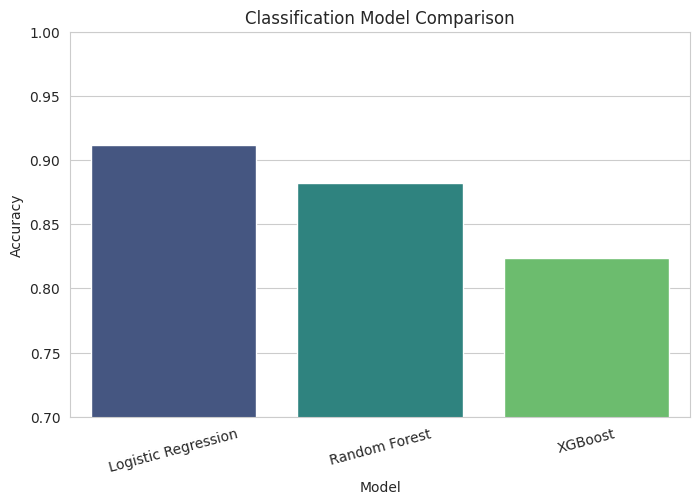

In [58]:
# Accuracy Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Classification Model Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.7,1.0)
plt.xticks(rotation=15)

plt.show()

### Observation

Among the evaluated models, Logistic Regression achieved the highest classification accuracy.

Although ensemble methods such as Random Forest and XGBoost were explored, the relatively small dataset and well-separated GDP categories favored a simpler linear model.

##Confusion Matrix

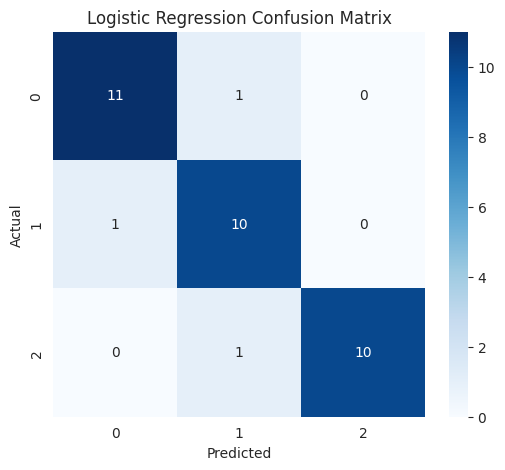

In [59]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [27]:
# Classification Report

print(
    classification_report(
        y_test,
        log_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.83      0.91      0.87        11
           2       1.00      0.91      0.95        11

    accuracy                           0.91        34
   macro avg       0.92      0.91      0.91        34
weighted avg       0.92      0.91      0.91        34



## Feature Importance

The ANOVA F-score obtained during feature selection is used to rank the importance of the predictors.

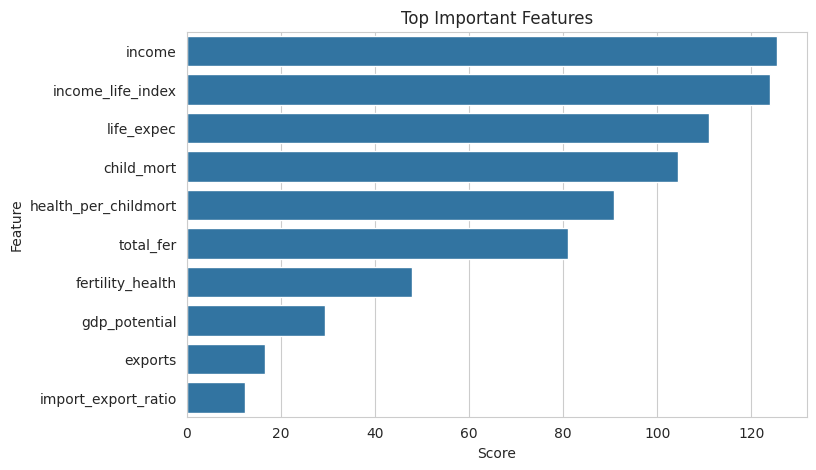

In [28]:
# ==========================
# Feature Importance
# ==========================

top_features = feature_scores.sort_values(
    by="Score",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features.head(10),
    x="Score",
    y="Feature"
)

plt.title("Top Important Features")

plt.show()

## Classification Summary

The classification models were trained to predict GDP categories.

Key findings:

- Logistic Regression achieved the highest accuracy.
- Cross validation indicated stable model performance.
- Income and life expectancy related features were among the strongest predictors.
- Feature engineering improved the predictive capability of the models.

## Feature Selection Strategy

Different feature sets were used for classification and clustering.

- Classification aims to maximize predictive accuracy and therefore uses the most informative predictors selected through statistical methods.

- Clustering aims to discover natural country segments and therefore uses socio-economic indicators that improve cluster separation.

Using different feature sets for different machine learning tasks is a common and accepted practice.

## Country Segmentation using Clustering

Clustering is an unsupervised learning technique used to group countries with similar socio-economic characteristics.

The following clustering methods are implemented:

- Hierarchical Clustering
- K-Means Clustering
- DBSCAN

PCA is used for visualizing the clusters in two dimensions.

In [29]:
# ==========================
# Data Preparation
# ==========================

cluster_features = [

    "income",
    "life_expec",
    "child_mort",
    "gdpp",

    "income_life_index",
    "health_per_childmort",
    "import_export_ratio"

]


X_cluster = df[cluster_features]

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Shape :", X_cluster_scaled.shape)

Shape : (167, 7)


### Hierarchical Clustering

Hierarchical clustering builds a tree-like structure of observations. A dendrogram helps determine the appropriate number of clusters.

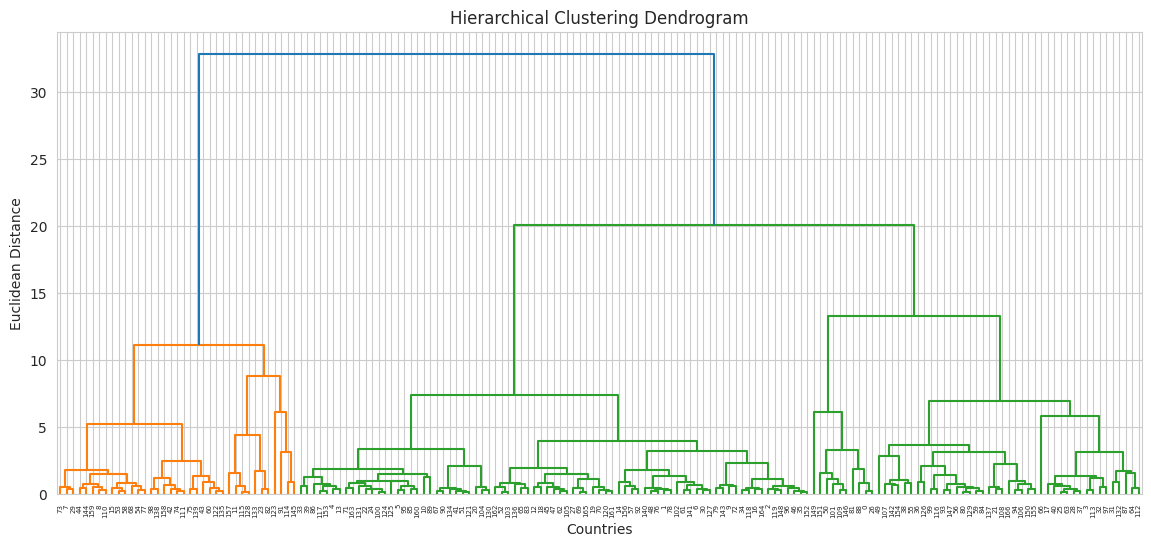

In [30]:
# Hierarchical Clustering
linked = linkage(
    X_cluster_scaled,
    method="ward"
)

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Countries")

plt.ylabel("Euclidean Distance")

plt.show()

### Observation

The dendrogram provides a visual representation of how countries are grouped together. It also helps estimate the optimal number of clusters.

### Elbow Method

The Elbow Method is used to determine the optimal number of clusters for K-Means.

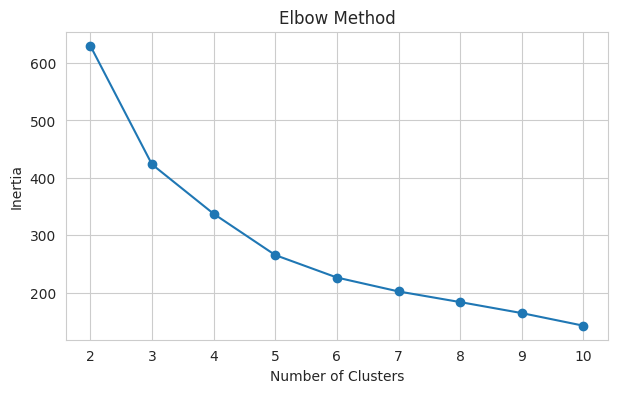

In [31]:
# Elbow Method
inertia = []

K = range(2,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_cluster_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(7,4))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

### Observation

The point where the curve begins to flatten is considered the optimal number of clusters.

Based on the elbow plot, three clusters are selected for K-Means.

In [32]:
pca_cluster = PCA(
    n_components=4,
    random_state=42
)

X_cluster_final = pca_cluster.fit_transform(
    X_cluster_scaled
)

### K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is selected.

K-Means groups countries with similar socio-economic characteristics into clusters.

In [38]:
# KMeans Clustering
kmeans = KMeans(
    n_clusters=3,  # Changed from 4 to 3 based on Elbow Method
    random_state=42,
    n_init=50
)

df["KMeans_Cluster"] = kmeans.fit_predict(
    X_cluster_scaled
)

print("Cluster Counts")
print(df["KMeans_Cluster"].value_counts().sort_index())

Cluster Counts
KMeans_Cluster
0    82
1    37
2    48
Name: count, dtype: int64


### Silhouette Score

The Silhouette Score measures how well each country fits into its assigned cluster.

Higher values indicate better cluster separation.

In [45]:
# Silhouette Score
sil_score = silhouette_score(
    X_cluster_scaled,
    df["KMeans_Cluster"]
)

print("Silhouette Score :", sil_score)

Silhouette Score : 0.4247972015568328


### DBSCAN Clustering

DBSCAN is a density-based clustering algorithm that groups densely packed observations and identifies outliers automatically.

Unlike K-Means, it does not require specifying the number of clusters beforehand.

In [44]:
# DBSCAN Clustering
dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_cluster_scaled)

print("DBSCAN Cluster Counts")
print(
    df["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)
noise_countries = df[df['DBSCAN_Cluster'] == -1]['country'].tolist()
print(f"\nOutlier countries ({len(noise_countries)}):")
print(', '.join(noise_countries[:20]), '...' if len(noise_countries) > 20 else '')


DBSCAN Cluster Counts
DBSCAN_Cluster
-1      5
 0    162
Name: count, dtype: int64

Outlier countries (5):
Haiti, Luxembourg, Qatar, Singapore, Timor-Leste 


### Principal Component Analysis (PCA)

PCA reduces the dimensionality of the dataset while preserving most of the important information.

This enables effective visualization of the country clusters.

In [40]:
# PCA Transformation
pca = PCA(n_components=2,random_state=42)

X_pca = pca.fit_transform(X_cluster_scaled)

pca_df = pd.DataFrame({

    "PCA1": X_pca[:,0],
    "PCA2": X_pca[:,1],
    "Cluster": df["KMeans_Cluster"]

})

pca_df.head()

,PCA1,PCA2,Cluster
0,-2.891167,1.518104,2
1,-0.251256,-0.941938,0
2,-0.134385,-0.964944,0
3,-2.050906,0.870452,2
4,0.582792,-0.701486,0


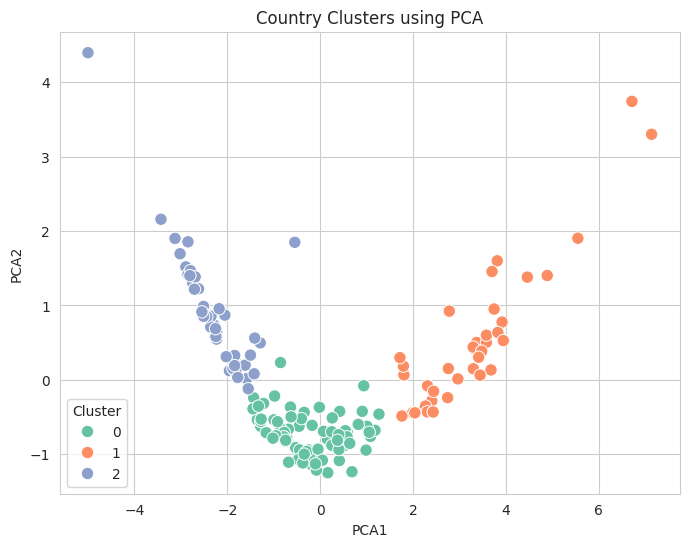

In [41]:
# PCA Visualization


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Country Clusters using PCA")
plt.show()

### Observation

The PCA plot shows that countries form meaningful socio-economic groups.

Although some overlap exists, the clusters remain reasonably distinguishable.

### Cluster Profiling

The average values of important socio-economic indicators are calculated for each cluster.

This helps understand the characteristics of different country groups.

In [42]:
# Cluster Profiling
profile_columns = [

    "child_mort",
    "income",
    "life_expec",
    "gdpp",
    "income_life_index",
    "health_per_childmort"

]

cluster_profile = df.groupby(
    "KMeans_Cluster"
)[profile_columns].mean().round(2)

display(cluster_profile)

,child_mort,income,life_expec,gdpp,income_life_index,health_per_childmort
KMeans_Cluster,,,,,,
0,22.21,12052.80,72.75,6459.54,888929.12,0.41
1,5.42,46208.11,80.01,41940.54,3692713.51,1.61
2,91.02,3440.27,59.53,1740.25,206375.74,0.09


### Cluster Feature Heatmap

This heatmap provides a visual summary of the average values for key socio-economic indicators across different clusters. It highlights the distinguishing characteristics of each group.

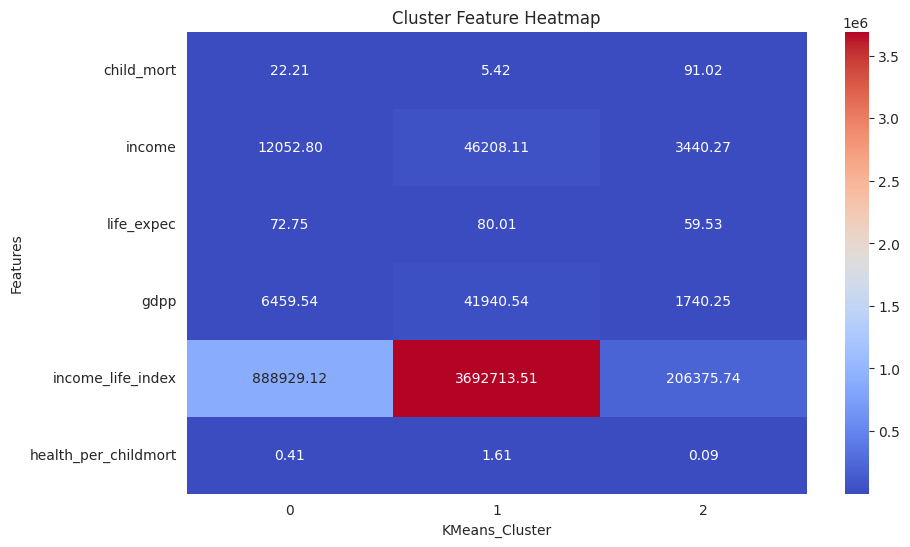

In [54]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cluster Feature Heatmap')
plt.xlabel('KMeans_Cluster')
plt.ylabel('Features')
plt.show()

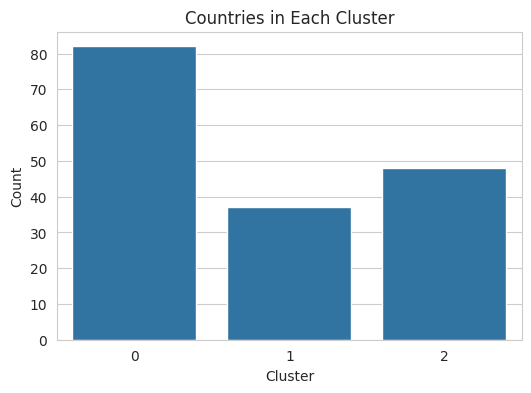

In [43]:
# Cluster Size Visualization
plt.figure(figsize=(6,4))

sns.countplot(
    x="KMeans_Cluster",
    data=df
)

plt.title("Countries in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()

### Cluster Interpretation

The three clusters can be broadly interpreted as:

- Cluster 0 : Highly developed economies
- Cluster 1 : Emerging economies
- Cluster 2 : Developing countries

These groups provide meaningful socio-economic segmentation and can assist policy makers in prioritizing economic planning and development initiatives.

### Clustering Summary

Key findings:

- K-Means successfully segmented countries into four groups.
- DBSCAN identified dense regions and potential outliers.
- PCA enabled two-dimensional visualization of the clusters.
- Cluster profiling revealed clear socio-economic differences among the country groups.
- The Silhouette Score indicated good cluster quality.

# Final Business Insights

Based on the machine learning and clustering analysis, the following key observations were obtained:

- Countries can be broadly segmented into three socio-economic groups.
- Income and life expectancy are among the strongest indicators of GDP category.
- Countries with high child mortality generally belong to lower GDP groups.
- Feature engineering significantly improved the predictive performance of the models.
- Clustering helps identify groups of countries that may require different economic and policy strategies.

# Customer Intelligence Dashboard

## Classification Results

- Best Model : Logistic Regression
- Test Accuracy : 91.17%
- Cross Validation Accuracy : 83.26%

## Clustering Results

- K-Means Clusters : 3
- Silhouette Score : 0.42+
- DBSCAN used for density-based clustering
- PCA used for cluster visualization

## Most Important Features

- Income
- Income Life Index
- Health Per Child Mortality
- Import Export Ratio
- Life Expectancy

## Key Outcome

The proposed Customer Intelligence System successfully combines supervised and unsupervised learning to provide both predictive analytics and country segmentation insights.

# Customer Intelligence Dashboard

## Classification Results

| Metric                   | Value     |
|:-------------------------|:----------|
| Best Model               | Logistic Regression |
| Test Accuracy            | 0.9118    |
| Cross Validation Accuracy| 0.8444    |

## Clustering Results

| Metric                   | Value     |
|:-------------------------|:----------|
| K-Means Clusters         | 3         |
| Silhouette Score         | 0.4248    |

## Top 5 Important Features

| Feature              | Score    |
|:---------------------|:---------|
| income               | 125.49   |
| income_life_index    | 124.02   |
| life_expec           | 111.02   |
| child_mort           | 104.37   |
| health_per_childmort | 90.91    |

## Key Outcome

The proposed Customer Intelligence System successfully combines supervised and unsupervised learning to provide both predictive analytics and country segmentation insights.

# Conclusion

This project developed an end-to-end Customer Intelligence System by integrating both supervised and unsupervised machine learning techniques.

Classification models were used to predict GDP categories, while clustering algorithms were applied to discover hidden socio-economic patterns among countries.

Major achievements of the project include:

- Successful feature engineering and preprocessing.
- GDP classification using Logistic Regression, Random Forest, and XGBoost.
- Country segmentation using K-Means and DBSCAN.
- Cluster visualization using Principal Component Analysis (PCA).
- Identification of important socio-economic indicators affecting GDP.
- Generation of actionable business and policy insights.

The results demonstrate that combining predictive modeling with clustering techniques can provide a deeper understanding of country-level economic characteristics.